In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [6]:
shape = df.shape
data_types = df.dtypes
summary_stats = df.describe()
missing_values = df.isnull().sum()
unique_values = df.select_dtypes(include=['object', 'category']).nunique()
target_value_counts = df['Is Fraudulent'].value_counts(normalize=True)
print(shape, data_types, summary_stats, missing_values, unique_values, target_value_counts)

(1472952, 16) Transaction ID         object
Customer ID            object
Transaction Amount    float64
Transaction Date       object
Payment Method         object
Product Category       object
Quantity                int64
Customer Age            int64
Customer Location      object
Device Used            object
IP Address             object
Shipping Address       object
Billing Address        object
Is Fraudulent           int64
Account Age Days        int64
Transaction Hour        int64
dtype: object        Transaction Amount      Quantity  Customer Age  Is Fraudulent  \
count        1.472952e+06  1.472952e+06  1.472952e+06   1.472952e+06   
mean         2.267683e+02  3.000230e+00  3.451208e+01   5.012926e-02   
std          2.703951e+02  1.414736e+00  1.000313e+01   2.182117e-01   
min          1.000000e+01  1.000000e+00 -1.600000e+01   0.000000e+00   
25%          6.861000e+01  2.000000e+00  2.800000e+01   0.000000e+00   
50%          1.517600e+02  3.000000e+00  3.500000e+01   0.00

In [7]:
num_rows = df.shape[0]
print(f"The number of rows in the dataset is: {num_rows}")

The number of rows in the dataset is: 1472952


In [8]:
missing_values = df.isnull().sum()
print(missing_values)

Transaction ID        0
Customer ID           0
Transaction Amount    0
Transaction Date      0
Payment Method        0
Product Category      0
Quantity              0
Customer Age          0
Customer Location     0
Device Used           0
IP Address            0
Shipping Address      0
Billing Address       0
Is Fraudulent         0
Account Age Days      0
Transaction Hour      0
dtype: int64


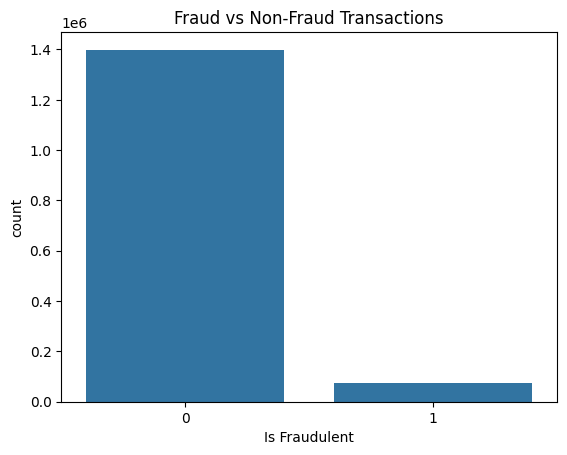

In [9]:
sns.countplot(x='Is Fraudulent', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

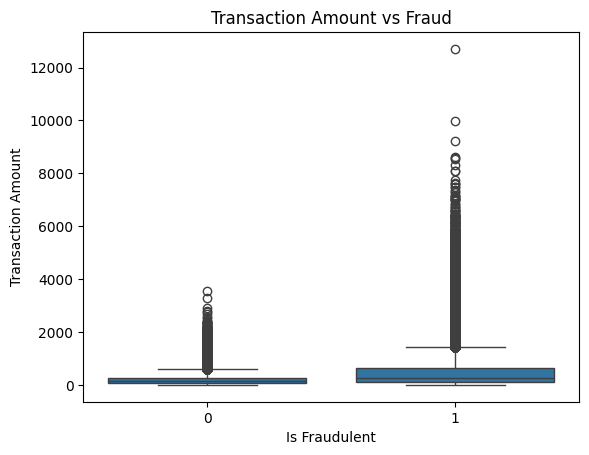

In [10]:
sns.boxplot(x='Is Fraudulent', y='Transaction Amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

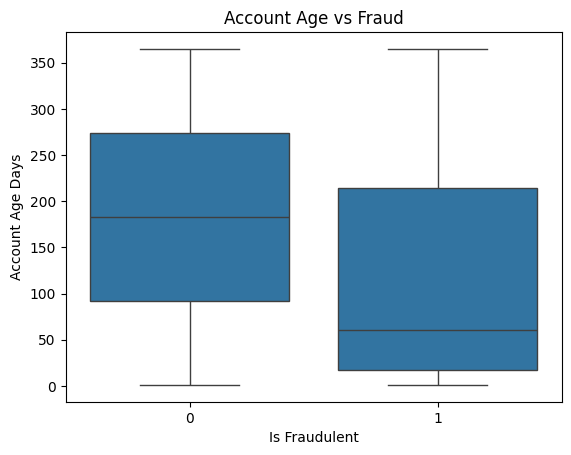

In [11]:
sns.boxplot(x='Is Fraudulent', y='Account Age Days', data=df)
plt.title("Account Age vs Fraud")
plt.show()

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

# Drop identifier columns (Transaction ID, Customer ID, IP Address)
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)

# Drop high-cardinality/unnecessary text-based location/address columns and Transaction Date
# 'Transaction Date' was causing ValueErrors for string to float conversion
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

# One-hot encode categorical features: Payment Method, Device Used, Product Category
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

# Define X and y
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Random Forest Classifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

# Drop identifier columns (Transaction ID, Customer ID, IP Address)
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)

# Drop high-cardinality/unnecessary text-based location/address columns and Transaction Date
# 'Transaction Date' was causing ValueErrors for string to float conversion
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

# One-hot encode categorical features: Payment Method, Device Used, Product Category
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

# Define X and y
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Random Forest Classifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

# Drop identifier columns (Transaction ID, Customer ID, IP Address)
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)

# Drop high-cardinality/unnecessary text-based location/address columns and Transaction Date
# 'Transaction Date' was causing ValueErrors for string to float conversion
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

# One-hot encode categorical features: Payment Method, Device Used, Product Category
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

# Define X and y
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Random Forest Classifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

# Drop identifier columns (Transaction ID, Customer ID, IP Address)
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)

# Drop high-cardinality/unnecessary text-based location/address columns and Transaction Date
# 'Transaction Date' was causing ValueErrors for string to float conversion
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

# One-hot encode categorical features: Payment Method, Device Used, Product Category
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

# Define X and y
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Random Forest Classifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

# Drop identifier columns (Transaction ID, Customer ID, IP Address)
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)

# Drop high-cardinality/unnecessary text-based location/address columns and Transaction Date
# 'Transaction Date' was causing ValueErrors for string to float conversion
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

# One-hot encode categorical features: Payment Method, Device Used, Product Category
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

# Define X and y
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Random Forest Classifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

# Drop identifier columns (Transaction ID, Customer ID, IP Address)
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)

# Drop high-cardinality/unnecessary text-based location/address columns and Transaction Date
# 'Transaction Date' was causing ValueErrors for string to float conversion
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

# One-hot encode categorical features: Payment Method, Device Used, Product Category
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

# Define X and y
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Random Forest Classifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')

# Drop identifier columns (Transaction ID, Customer ID, IP Address)
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)

# Drop high-cardinality/unnecessary text-based location/address columns and Transaction Date
# 'Transaction Date' was causing ValueErrors for string to float conversion
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

# One-hot encode categorical features: Payment Method, Device Used, Product Category
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

# Define X and y
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Random Forest Classifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
df = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df = df.drop(['Transaction ID', 'Customer ID', 'IP Address'], axis=1)
df = pd.get_dummies(df, columns=['Payment Method', 'Device Used', 'Product Category'], drop_first=True)

In [ ]:
df = df.drop(['Transaction Date', 'Customer Location', 'Shipping Address', 'Billing Address'], axis=1)

In [ ]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

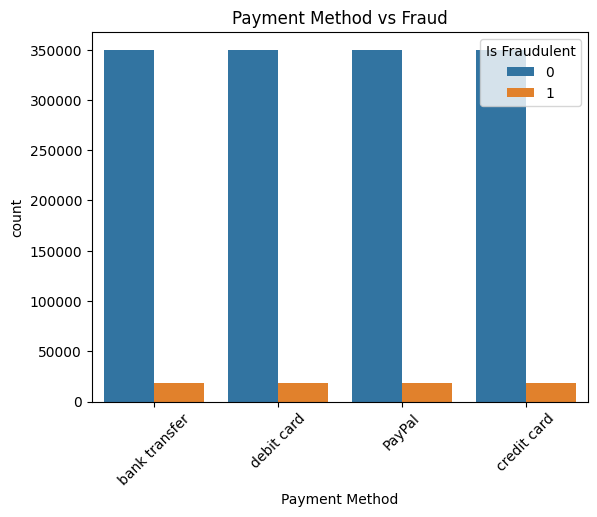

In [12]:
sns.countplot(x='Payment Method', hue='Is Fraudulent', data=df)
plt.title("Payment Method vs Fraud")
plt.xticks(rotation=45)
plt.show()

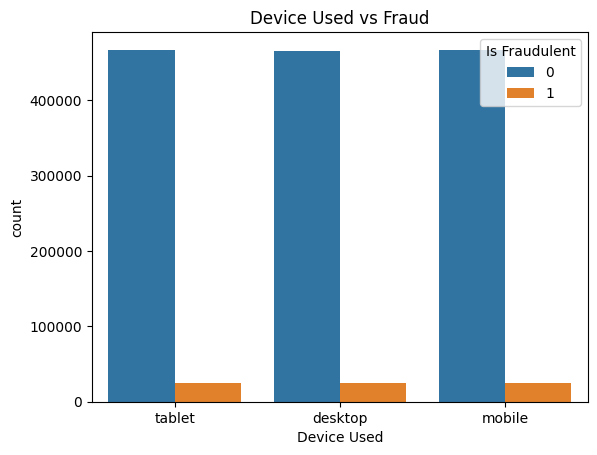

In [13]:
sns.countplot(x='Device Used', hue='Is Fraudulent', data=df)
plt.title("Device Used vs Fraud")
plt.show()

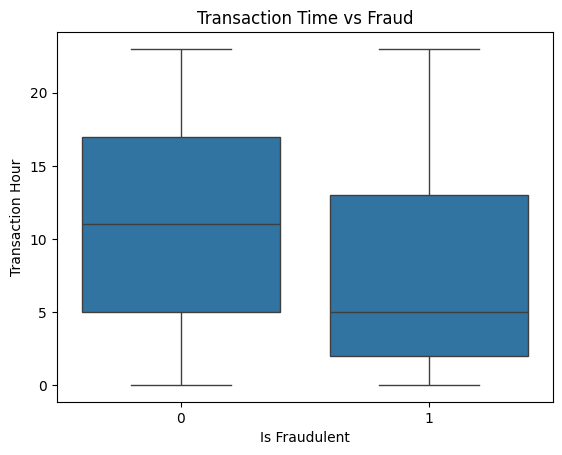

In [14]:
sns.boxplot(x='Is Fraudulent', y='Transaction Hour', data=df)
plt.title("Transaction Time vs Fraud")
plt.show()

TO TRAIN DAATA I'M TAKING SAMPLES

In [68]:
df = df.sample(n=20000, random_state=42)

In [70]:
shape = df.shape
print(shape)

(20000, 15)


In [72]:
df = pd.get_dummies(df, drop_first=True)

In [73]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [76]:
y_pred = model.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9605

Confusion Matrix:
 [[3811    9]
 [ 149   31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      3820
           1       0.78      0.17      0.28       180

    accuracy                           0.96      4000
   macro avg       0.87      0.58      0.63      4000
weighted avg       0.95      0.96      0.95      4000



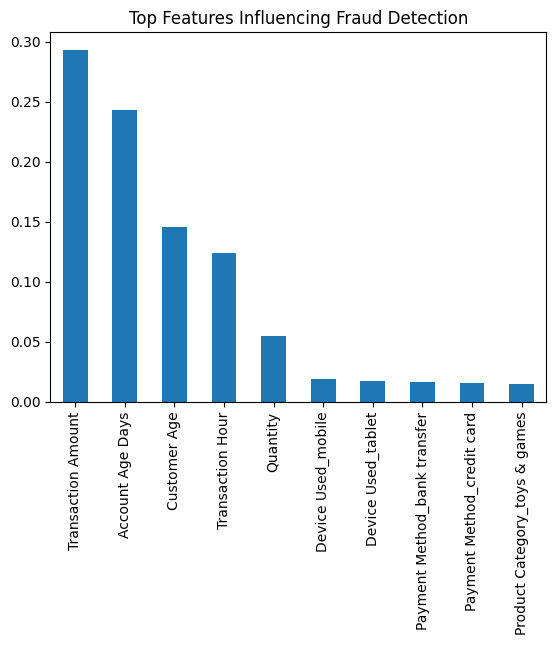

In [79]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features Influencing Fraud Detection")
plt.show()

In [80]:
accuracy_score(y_test, y_pred)

0.9605